In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [11]:
# load the arrays
import numpy as np

X = np.load("/content/drive/MyDrive/.npy_files/NEW_ROI_X.npy")
Y = np.load("/content/drive/MyDrive/.npy_files/NEW_ROI_Y.npy")

print("X shape:", X.shape)
print("Y shape:", Y.shape)

print("X dtype:", X.dtype)
print("Y dtype:", Y.dtype)

X shape: (3242, 128, 128, 1)
Y shape: (3242, 128, 128, 1)
X dtype: float32
Y dtype: uint8


In [12]:
print(X.shape)
print(Y.shape)
print(X.dtype)
print(Y.dtype)
print(np.unique(Y))

(3242, 128, 128, 1)
(3242, 128, 128, 1)
float32
uint8
[0 1]


In [13]:
print("X min :", X.min())
print("X max :", X.max())

print("Unique mask values:")
print(np.unique(Y))

X min : 0.003921569
X max : 1.0000001
Unique mask values:
[0 1]


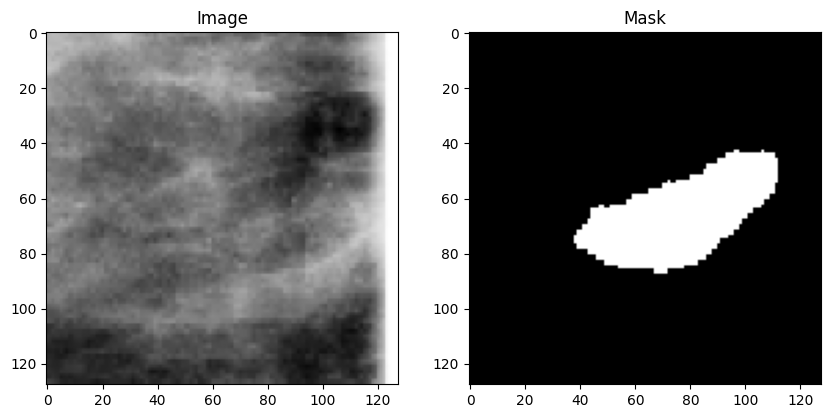

In [14]:
# display one image
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(X[0].squeeze(), cmap="gray")
plt.title("Image")

plt.subplot(1,2,2)
plt.imshow(Y[0].squeeze(), cmap="gray")
plt.title("Mask")

plt.show()

In [15]:
from sklearn.model_selection import train_test_split

# 70% Train, 30% Temp
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# 15% Validation, 15% Test
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Training Set")
print(X_train.shape, Y_train.shape)

print("\nValidation Set")
print(X_val.shape, Y_val.shape)

print("\nTesting Set")
print(X_test.shape, Y_test.shape)

Training Set
(2269, 128, 128, 1) (2269, 128, 128, 1)

Validation Set
(486, 128, 128, 1) (486, 128, 128, 1)

Testing Set
(487, 128, 128, 1) (487, 128, 128, 1)


In [16]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device:", device)

Using Device: cuda


In [17]:
# load dataset
X = np.load("/content/drive/MyDrive/.npy_files/NEW_ROI_X.npy")
Y = np.load("/content/drive/MyDrive/.npy_files/NEW_ROI_Y.npy")


print("Images :", X.shape)
print("Masks  :", Y.shape)

Images : (3242, 128, 128, 1)
Masks  : (3242, 128, 128, 1)


In [18]:
# split dataset
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42,
    shuffle=True
)

print("Train :", X_train.shape)
print("Val   :", X_val.shape)
print("Test  :", X_test.shape)

Train : (2269, 128, 128, 1)
Val   : (486, 128, 128, 1)
Test  : (487, 128, 128, 1)


In [19]:
# py-torch dataset class
class MammogramDataset(Dataset):

    def __init__(self, images, masks):
        self.images = images
        self.masks = masks

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = torch.tensor(
            self.images[idx],
            dtype=torch.float32
        ).permute(2,0,1)

        mask = torch.tensor(
            self.masks[idx],
            dtype=torch.float32
        ).permute(2,0,1)

        return image, mask

In [20]:
# Data loaders
BATCH_SIZE = 8

train_dataset = MammogramDataset(X_train, Y_train)
val_dataset = MammogramDataset(X_val, Y_val)
test_dataset = MammogramDataset(X_test, Y_test)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))

Train batches: 284


In [21]:
images, masks = next(iter(train_loader))

print("Images Shape :", images.shape)
print("Masks Shape  :", masks.shape)

print("Images dtype :", images.dtype)
print("Masks dtype  :", masks.dtype)

print("Mask values  :", torch.unique(masks))

Images Shape : torch.Size([8, 1, 128, 128])
Masks Shape  : torch.Size([8, 1, 128, 128])
Images dtype : torch.float32
Masks dtype  : torch.float32
Mask values  : tensor([0., 1.])


In [22]:
# verify dataloader
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

torch.Size([8, 1, 128, 128])
torch.Size([8, 1, 128, 128])


In [23]:
!pip install -q segmentation-models-pytorch
!pip install -q torchmetrics

In [24]:
import segmentation_models_pytorch as smp

import torch
import torch.nn as nn
import torch.optim as optim

from torchmetrics.classification import (
    BinaryAccuracy,
    BinaryPrecision,
    BinaryRecall,
    BinaryF1Score
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

cuda


In [25]:
model = smp.UnetPlusPlus(

    encoder_name="resnet34",
    encoder_weights="imagenet",

    in_channels=1,
    classes=1,

    activation=None

)

model = model.to(device)

print(model)

UnetPlusPlus(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

In [26]:
images, masks = next(iter(train_loader))

images = images.to(device)

outputs = model(images)

print("Output Shape :", outputs.shape)
print("Output dtype :", outputs.dtype)

Output Shape : torch.Size([8, 1, 128, 128])
Output dtype : torch.float32


In [27]:
bce_loss = nn.BCEWithLogitsLoss()

dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)

def total_loss(pred, target):

    bce = bce_loss(pred, target)
    dice = dice_loss(pred, target)

    return bce + dice

In [28]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-5,
    weight_decay=1e-4
)

In [29]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="max",

    factor=0.5,

    patience=2

)

In [30]:
accuracy = BinaryAccuracy().to(device)

precision = BinaryPrecision().to(device)

recall = BinaryRecall().to(device)

f1 = BinaryF1Score().to(device)

In [31]:
def dice_score(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred)

    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum()

    return (2 * intersection + smooth) / (union + smooth)

In [32]:
def iou_score(pred, target, smooth=1e-6):

    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    return (intersection + smooth) / (union + smooth)

In [33]:
# Training Function
def train_one_epoch(model, loader, optimizer):

    model.train()

    running_loss = 0
    running_dice = 0
    running_iou = 0

    progress = tqdm(loader, desc="Training", leave=False)

    for images, masks in progress:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = total_loss(outputs, masks)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()
        running_dice += dice_score(outputs, masks).item()
        running_iou += iou_score(outputs, masks).item()

        progress.set_postfix(loss=loss.item())

    epoch_loss = running_loss / len(loader)
    epoch_dice = running_dice / len(loader)
    epoch_iou = running_iou / len(loader)

    return epoch_loss, epoch_dice, epoch_iou

In [34]:
# Validation function
def validate(model, loader):

    model.eval()

    running_loss = 0
    running_dice = 0
    running_iou = 0

    acc = 0
    prec = 0
    rec = 0
    f1score = 0

    with torch.no_grad():

        progress = tqdm(loader, desc="Validation", leave=False)

        for images, masks in progress:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = total_loss(outputs, masks)

            running_loss += loss.item()

            running_dice += dice_score(outputs, masks).item()
            running_iou += iou_score(outputs, masks).item()

            preds = (torch.sigmoid(outputs) > 0.5).float()

            acc += accuracy(preds, masks).item()
            prec += precision(preds, masks).item()
            rec += recall(preds, masks).item()
            f1score += f1(preds, masks).item()

    epoch_loss = running_loss / len(loader)
    epoch_dice = running_dice / len(loader)
    epoch_iou = running_iou / len(loader)

    epoch_acc = acc / len(loader)
    epoch_prec = prec / len(loader)
    epoch_rec = rec / len(loader)
    epoch_f1 = f1score / len(loader)

    return (
        epoch_loss,
        epoch_dice,
        epoch_iou,
        epoch_acc,
        epoch_prec,
        epoch_rec,
        epoch_f1
    )

In [35]:
best_dice = 0

early_stop_counter = 0
early_stop_patience = 5

In [36]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "val_iou": [],
}

In [37]:
EPOCHS = 50

best_dice = float("-inf")

history = {
    "train_loss": [],
    "val_loss": [],
    "train_dice": [],
    "val_dice": [],
    "train_iou": [],
    "val_iou": [],
    "accuracy": [],
    "precision": [],
    "recall": [],
    "f1": []
}

for epoch in range(EPOCHS):

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    train_loss, train_dice, train_iou = train_one_epoch(
        model,
        train_loader,
        optimizer
    )

    (
        val_loss,
        val_dice,
        val_iou,
        val_acc,
        val_prec,
        val_rec,
        val_f1

    ) = validate(model, val_loader)

    scheduler.step(val_dice)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_dice"].append(train_dice)
    history["val_dice"].append(val_dice)

    history["train_iou"].append(train_iou)
    history["val_iou"].append(val_iou)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Val Loss   : {val_loss:.4f}")

    print(f"Train Dice : {train_dice:.4f}")
    print(f"Val Dice   : {val_dice:.4f}")

    print(f"Val IoU    : {val_iou:.4f}")

    print(f"Accuracy   : {val_acc:.4f}")
    print(f"Precision  : {val_prec:.4f}")
    print(f"Recall     : {val_rec:.4f}")
    print(f"F1 Score   : {val_f1:.4f}")

if val_dice > best_dice:

    best_dice = val_dice
    early_stop_counter = 0

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_dice": best_dice,
        "val_loss": val_loss,
        "scheduler_state_dict": scheduler.state_dict(),
    }

    torch.save(
        checkpoint,
        "/content/drive/MyDrive/ELC/best_unetplusplus_checkpoint.pth"
    )

    print("✅ Best model saved!")

else:

    early_stop_counter += 1

    print(f"EarlyStopping Counter: {early_stop_counter}/{early_stop_patience}")

    if early_stop_counter >= early_stop_patience:

        print("\n🛑 Early stopping triggered!")

         break


Epoch [1/50]


Train Loss : 0.9673
Val Loss   : 0.7177
Train Dice : 0.6793
Val Dice   : 0.8009
Val IoU    : 0.6703
Accuracy   : 0.9685
Precision  : 0.7924
Recall     : 0.8143
F1 Score   : 0.8009

Epoch [2/50]


Train Loss : 0.6121
Val Loss   : 0.5456
Train Dice : 0.8007
Val Dice   : 0.7946
Val IoU    : 0.6620
Accuracy   : 0.9648
Precision  : 0.7284
Recall     : 0.8794
F1 Score   : 0.7946

Epoch [3/50]


Train Loss : 0.4545
Val Loss   : 0.4418
Train Dice : 0.8221
Val Dice   : 0.8011
Val IoU    : 0.6718
Accuracy   : 0.9690
Precision  : 0.8094
Recall     : 0.8014
F1 Score   : 0.8011

Epoch [4/50]


Train Loss : 0.3626
Val Loss   : 0.3648
Train Dice : 0.8363
Val Dice   : 0.8216
Val IoU    : 0.6998
Accuracy   : 0.9714
Precision  : 0.8102
Recall     : 0.8387
F1 Score   : 0.8216

Epoch [5/50]


...

Train Loss : 0.1018
Val Loss   : 0.3202
Train Dice : 0.9428
Val Dice   : 0.8128
Val IoU    : 0.6869
Accuracy   : 0.9713
Precision  : 0.8304
Recall     : 0.8002
F1 Score   : 0.8128

Epoch [48/50]


Train Loss : 0.1018
Val Loss   : 0.3224
Train Dice : 0.9427
Val Dice   : 0.8110
Val IoU    : 0.6844
Accuracy   : 0.9711
Precision  : 0.8289
Recall     : 0.7982
F1 Score   : 0.8110

Epoch [49/50]


Train Loss : 0.1035
Val Loss   : 0.3210
Train Dice : 0.9416
Val Dice   : 0.8130
Val IoU    : 0.6872
Accuracy   : 0.9713
Precision  : 0.8269
Recall     : 0.8038
F1 Score   : 0.8130

Epoch [50/50]


Train Loss : 0.1020
Val Loss   : 0.3207
Train Dice : 0.9427
Val Dice   : 0.8129
Val IoU    : 0.6871
Accuracy   : 0.9711
Precision  : 0.8232
Recall     : 0.8073
F1 Score   : 0.8129


SyntaxError: 'break' outside loop (2287866699.py, line 94)

In [38]:
import torch
import os

save_dir = "/content/drive/MyDrive/ELC"
os.makedirs(save_dir, exist_ok=True)

checkpoint = {
    "epoch": 49,   # completed 50 epochs (0-indexed)
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "best_dice": best_dice,
}

torch.save(
    checkpoint,
    os.path.join(save_dir, "best_unetplusplus_checkpoint.pth")
)

print("✅ Checkpoint saved successfully!")

✅ Checkpoint saved successfully!


In [39]:
import pickle

with open(os.path.join(save_dir, "history.pkl"), "wb") as f:
    pickle.dump(history, f)

print("✅ History saved successfully!")

✅ History saved successfully!


In [40]:
import os

save_dir = "/content/drive/MyDrive/ELC"

if os.path.exists(save_dir):
    print("Files in ELC folder:")
    print(os.listdir(save_dir))
else:
    print("ELC folder does not exist.")

Files in ELC folder:
['X.npy', 'Y.npy', 'Copy_of_Untitled4.ipynb', 'best_unetplusplus_checkpoint.pth', 'history.pkl']


In [41]:
import pickle

with open("/content/drive/MyDrive/ELC/history.pkl", "wb") as f:
    pickle.dump(history, f)

print("History saved!")

History saved!


In [42]:
checkpoint = torch.load(
    "/content/drive/MyDrive/ELC/best_unetplusplus_checkpoint.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])

optimizer.load_state_dict(checkpoint["optimizer_state_dict"])

best_dice = checkpoint["best_dice"]

start_epoch = checkpoint["epoch"] + 1

print("Resumed from epoch:", start_epoch)

Resumed from epoch: 50


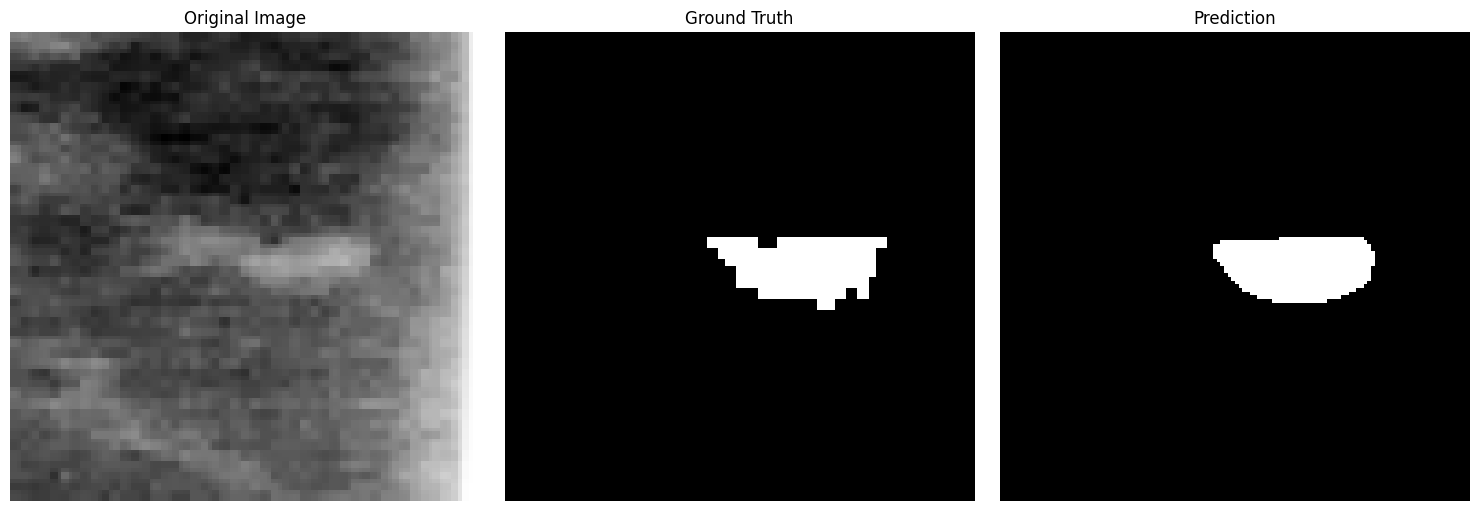

In [43]:
import random
import matplotlib.pyplot as plt
import numpy as np
import torch

# Put model in evaluation mode
model.eval()

# Select a random image
idx = random.randint(0, len(X)-1)

image = X[idx]      # (256,256,1)
mask = Y[idx]       # (256,256,1)

# Convert image to tensor
image_tensor = torch.from_numpy(image).permute(2,0,1).unsqueeze(0).float().to(device)

with torch.no_grad():
    pred = model(image_tensor)
    pred = torch.sigmoid(pred)
    pred = (pred > 0.5).float()

pred_mask = pred.squeeze().cpu().numpy()

# Plot
plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(image.squeeze(), cmap='gray')
plt.title("Original Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Ground Truth")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(pred_mask, cmap='gray')
plt.title("Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

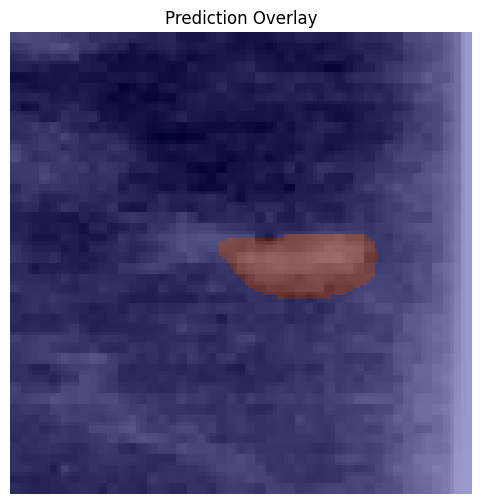

In [44]:
plt.figure(figsize=(6,6))

plt.imshow(image.squeeze(), cmap='gray')
plt.imshow(pred_mask, cmap='jet', alpha=0.4)

plt.title("Prediction Overlay")
plt.axis("off")
plt.show()

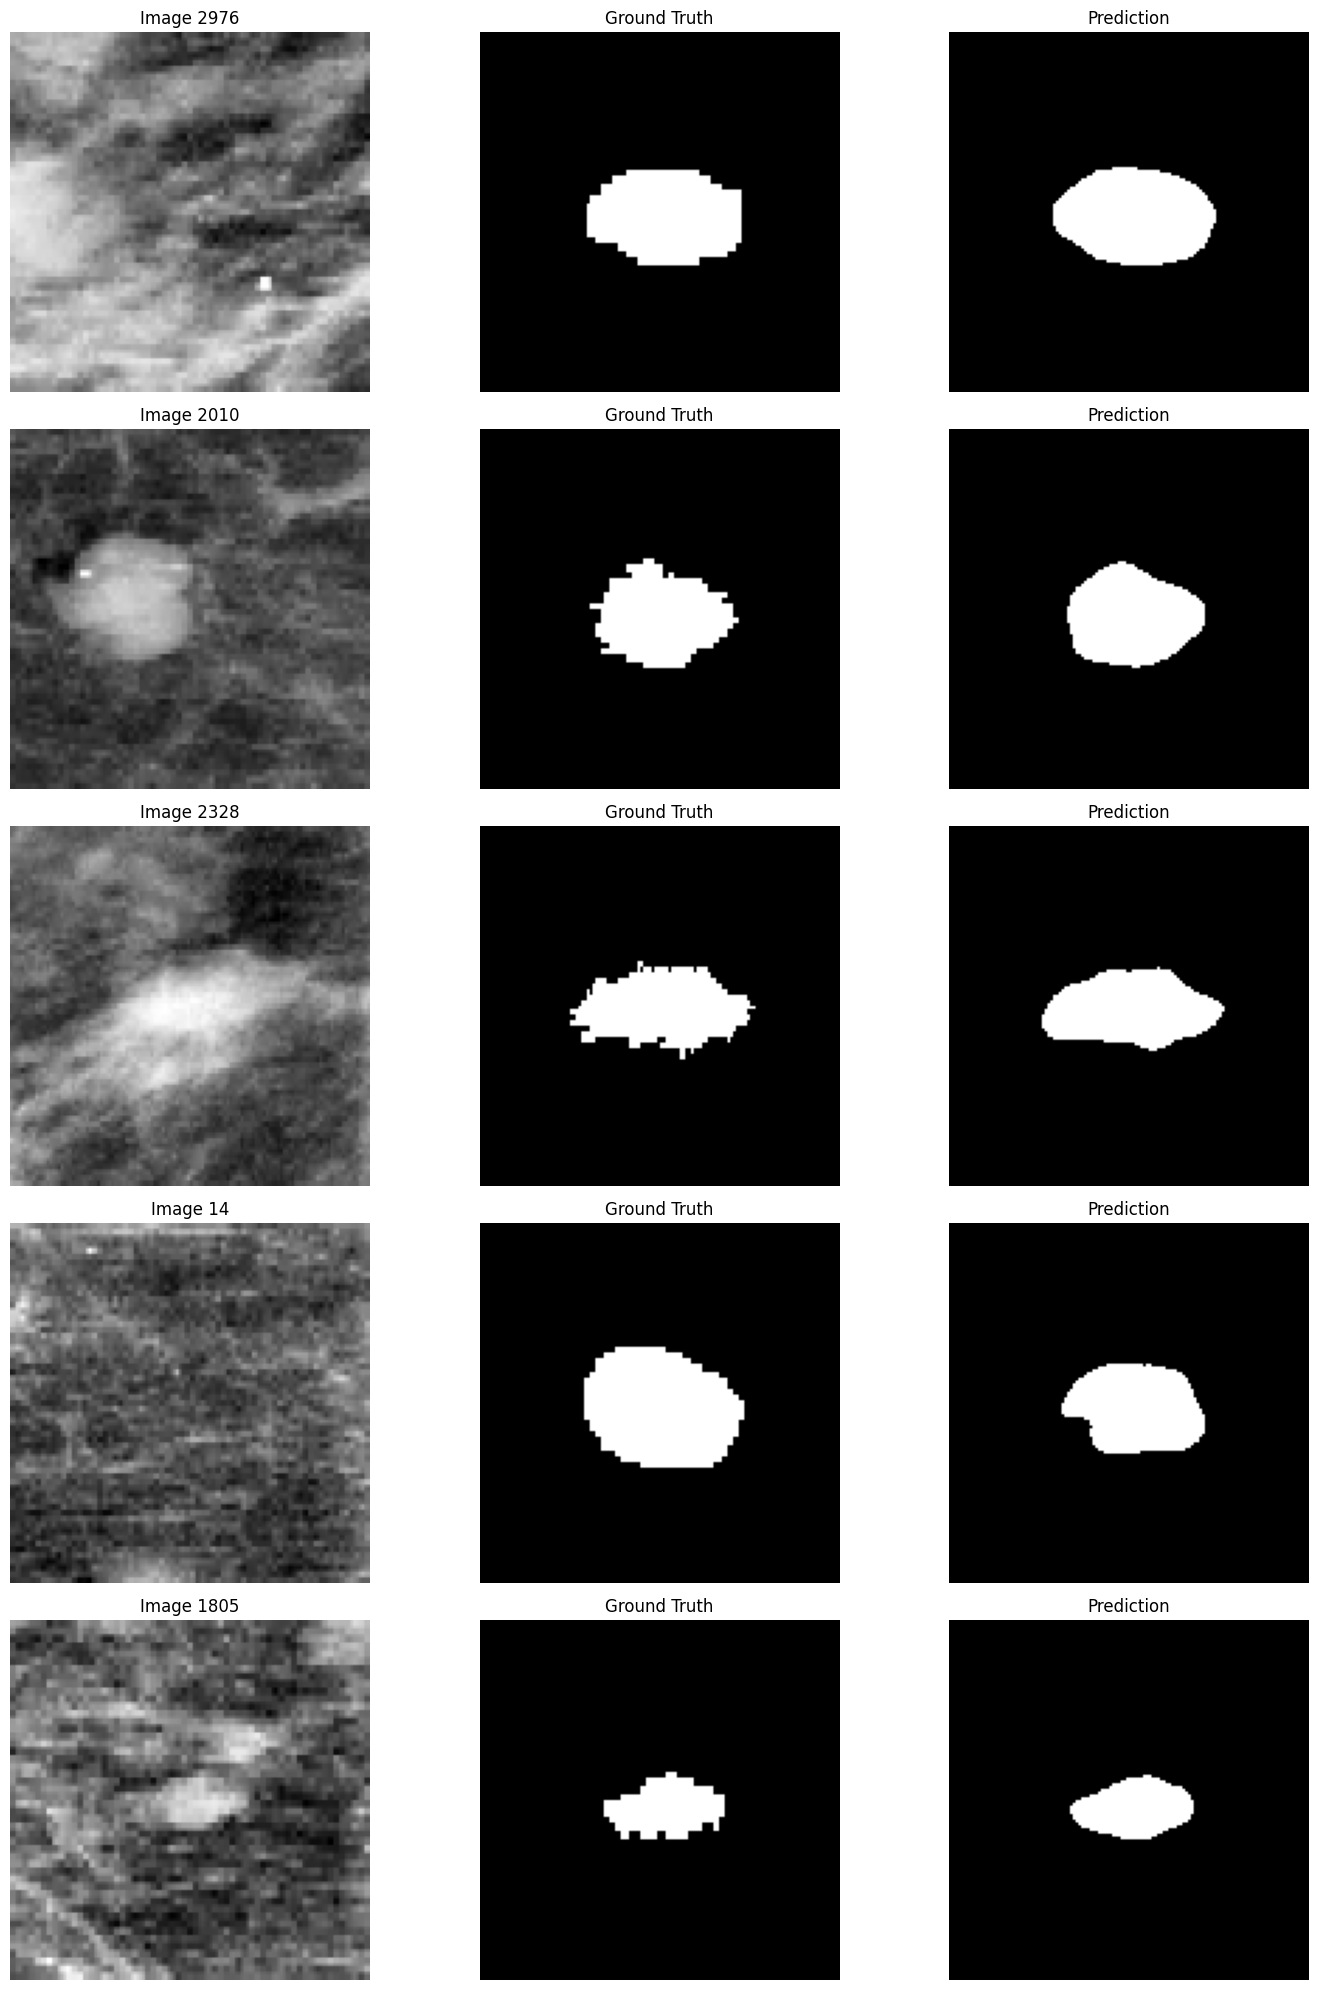

In [46]:
import random
import matplotlib.pyplot as plt
import torch
import numpy as np

# Set model to evaluation mode
model.eval()

# Select 5 random indices
indices = random.sample(range(len(X)), 5)

plt.figure(figsize=(15, 20))

for i, idx in enumerate(indices):

    # Get image and mask
    image = X[idx]          # (256,256,1)
    mask = Y[idx]           # (256,256,1)

    # Convert image to tensor
    image_tensor = (
        torch.from_numpy(image)
        .permute(2, 0, 1)
        .unsqueeze(0)
        .float()
        .to(device)
    )

    # Prediction
    with torch.no_grad():
        pred = model(image_tensor)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()

    pred_mask = pred.squeeze().cpu().numpy()

    # Original Image
    plt.subplot(5, 3, 3*i + 1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(f"Image {idx}")
    plt.axis("off")

    # Ground Truth
    plt.subplot(5, 3, 3*i + 2)
    plt.imshow(mask.squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(5, 3, 3*i + 3)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

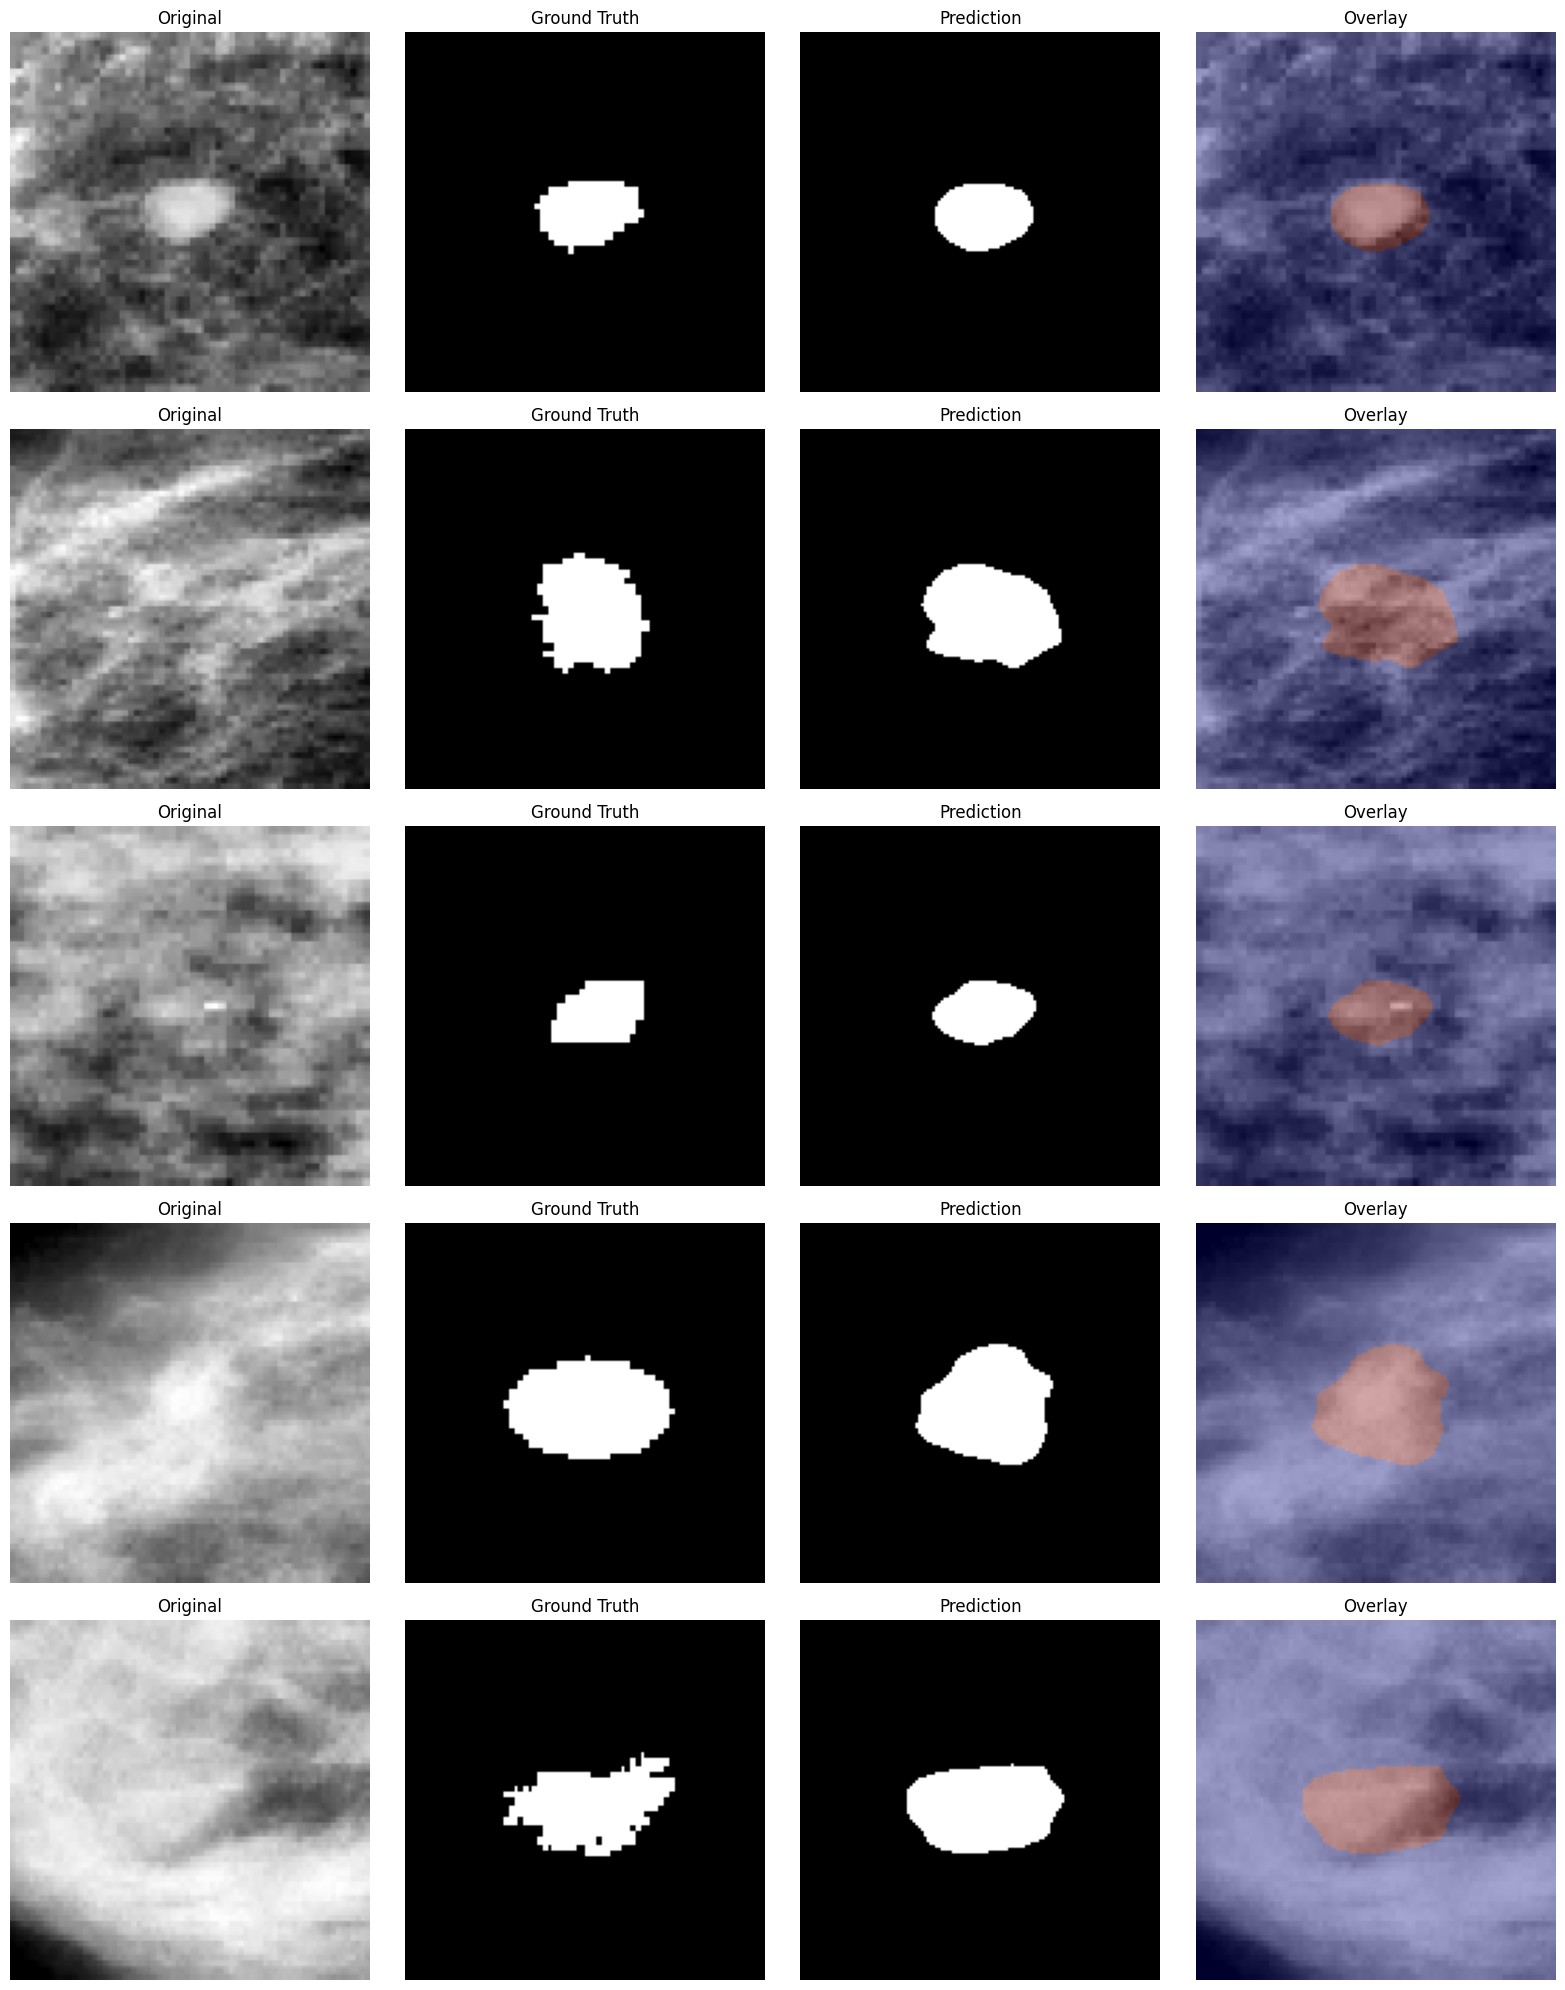

In [47]:
import random
import torch
import matplotlib.pyplot as plt

model.eval()

indices = random.sample(range(len(X_test)), 5)

plt.figure(figsize=(16,20))

for i, idx in enumerate(indices):

    image = X_test[idx]
    mask = Y_test[idx]

    image_tensor = (
        torch.from_numpy(image)
        .permute(2,0,1)
        .unsqueeze(0)
        .float()
        .to(device)
    )

    with torch.no_grad():
        pred = model(image_tensor)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()

    pred_mask = pred.squeeze().cpu().numpy()

    # Original Image
    plt.subplot(5,4,4*i+1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Ground Truth
    plt.subplot(5,4,4*i+2)
    plt.imshow(mask.squeeze(), cmap='gray')
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(5,4,4*i+3)
    plt.imshow(pred_mask, cmap='gray')
    plt.title("Prediction")
    plt.axis("off")

    # Overlay
    plt.subplot(5,4,4*i+4)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.imshow(pred_mask, cmap='jet', alpha=0.35)
    plt.title("Overlay")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [48]:
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score
import numpy as np
import torch

model.eval()

dice_scores = []
iou_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

with torch.no_grad():

    for i in range(len(X_test)):

        image = X_test[i]
        mask = Y_test[i]

        image_tensor = (
            torch.from_numpy(image)
            .permute(2,0,1)
            .unsqueeze(0)
            .float()
            .to(device)
        )

        pred = model(image_tensor)
        pred = torch.sigmoid(pred)
        pred = (pred > 0.5).float()

        pred_mask = pred.squeeze().cpu().numpy().astype(np.uint8)
        gt_mask = mask.squeeze().astype(np.uint8)

        # Flatten
        y_true = gt_mask.flatten()
        y_pred = pred_mask.flatten()

        # Dice
        intersection = np.sum(y_true * y_pred)

        dice = (2 * intersection + 1e-6) / (
            np.sum(y_true) + np.sum(y_pred) + 1e-6
        )

        dice_scores.append(dice)

        # IoU
        iou_scores.append(
            jaccard_score(
                y_true,
                y_pred,
                zero_division=0
            )
        )

        # Precision
        precision_scores.append(
            precision_score(
                y_true,
                y_pred,
                zero_division=0
            )
        )

        # Recall
        recall_scores.append(
            recall_score(
                y_true,
                y_pred,
                zero_division=0
            )
        )

        # F1
        f1_scores.append(
            f1_score(
                y_true,
                y_pred,
                zero_division=0
            )
        )

In [49]:
print("="*45)
print("TEST SET RESULTS")
print("="*45)

print(f"Mean Dice Score : {np.mean(dice_scores):.4f}")
print(f"Mean IoU        : {np.mean(iou_scores):.4f}")
print(f"Mean Precision  : {np.mean(precision_scores):.4f}")
print(f"Mean Recall     : {np.mean(recall_scores):.4f}")
print(f"Mean F1 Score   : {np.mean(f1_scores):.4f}")

TEST SET RESULTS
Mean Dice Score : 0.8033
Mean IoU        : 0.6862
Mean Precision  : 0.8204
Mean Recall     : 0.8172
Mean F1 Score   : 0.8033


In [50]:
# save the results
results = {
    "Dice": np.mean(dice_scores),
    "IoU": np.mean(iou_scores),
    "Precision": np.mean(precision_scores),
    "Recall": np.mean(recall_scores),
    "F1": np.mean(f1_scores)
}

print(results)

{'Dice': np.float64(0.8033218088516122), 'IoU': np.float64(0.6861554855366808), 'Precision': np.float64(0.8203831419620434), 'Recall': np.float64(0.8171999871833059), 'F1': np.float64(0.8033218086859303)}


In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score, jaccard_score
import numpy as np
import torch

def evaluate_dataset(model, X_data, Y_data, device):

    model.eval()

    dice_scores = []
    iou_scores = []
    precision_scores = []
    recall_scores = []
    f1_scores = []

    with torch.no_grad():

        for i in range(len(X_data)):

            image = X_data[i]
            mask = Y_data[i]

            image_tensor = (
                torch.from_numpy(image)
                .permute(2,0,1)
                .unsqueeze(0)
                .float()
                .to(device)
            )

            pred = model(image_tensor)
            pred = torch.sigmoid(pred)
            pred = (pred > 0.5).float()

            pred_mask = pred.squeeze().cpu().numpy().astype(np.uint8)
            gt_mask = mask.squeeze().astype(np.uint8)

            y_true = gt_mask.flatten()
            y_pred = pred_mask.flatten()

            # Dice
            intersection = np.sum(y_true * y_pred)

            dice = (2 * intersection + 1e-6) / (
                np.sum(y_true) + np.sum(y_pred) + 1e-6
            )

            dice_scores.append(dice)

            # IoU
            iou_scores.append(
                jaccard_score(y_true, y_pred, zero_division=0)
            )

            precision_scores.append(
                precision_score(y_true, y_pred, zero_division=0)
            )

            recall_scores.append(
                recall_score(y_true, y_pred, zero_division=0)
            )

            f1_scores.append(
                f1_score(y_true, y_pred, zero_division=0)
            )

    return {
        "Dice": np.mean(dice_scores),
        "IoU": np.mean(iou_scores),
        "Precision": np.mean(precision_scores),
        "Recall": np.mean(recall_scores),
        "F1": np.mean(f1_scores)
    }

In [52]:
train_results = evaluate_dataset(model, X_train, Y_train, device)

val_results = evaluate_dataset(model, X_val, Y_val, device)

test_results = evaluate_dataset(model, X_test, Y_test, device)

In [53]:
import pandas as pd

results_df = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Dice": [
        train_results["Dice"],
        val_results["Dice"],
        test_results["Dice"]
    ],
    "IoU": [
        train_results["IoU"],
        val_results["IoU"],
        test_results["IoU"]
    ],
    "Precision": [
        train_results["Precision"],
        val_results["Precision"],
        test_results["Precision"]
    ],
    "Recall": [
        train_results["Recall"],
        val_results["Recall"],
        test_results["Recall"]
    ],
    "F1 Score": [
        train_results["F1"],
        val_results["F1"],
        test_results["F1"]
    ]
})

results_df = results_df.round(4)

print(results_df)

      Dataset    Dice     IoU  Precision  Recall  F1 Score
0       Train  0.9255  0.8679     0.9320  0.9244    0.9255
1  Validation  0.7942  0.6772     0.8160  0.8098    0.7942
2        Test  0.8033  0.6862     0.8204  0.8172    0.8033


In [54]:
results_df.to_csv(
    "/content/drive/MyDrive/ELC/Final_Model_Results.csv",
    index=False
)

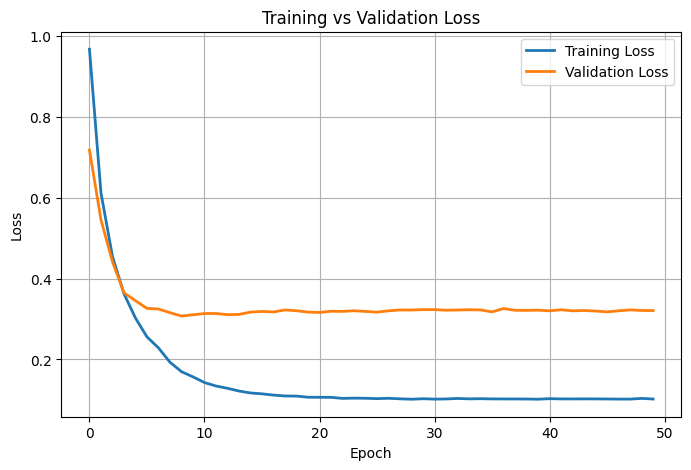

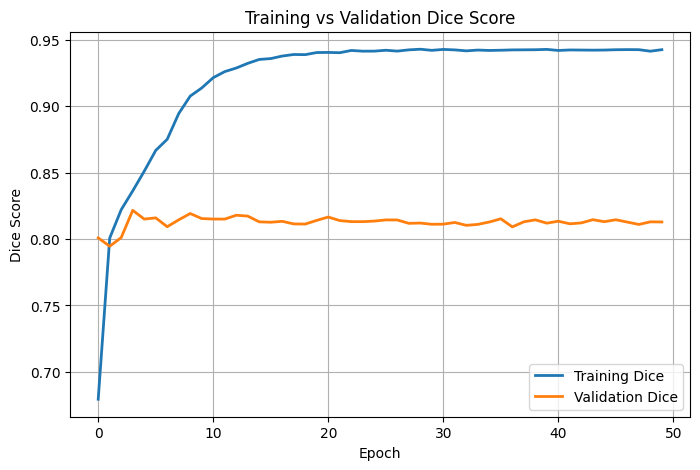

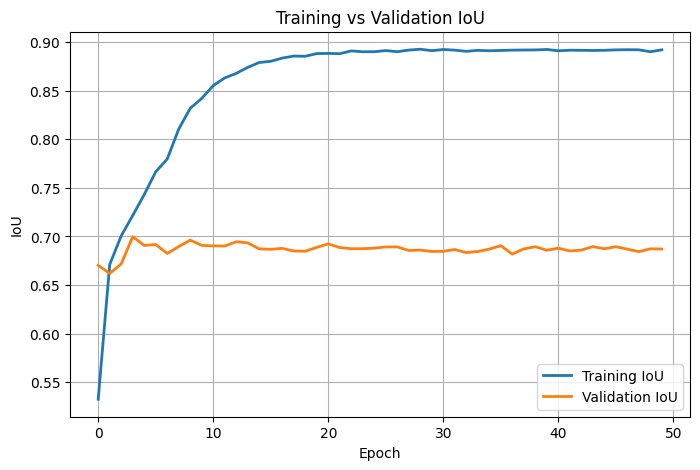

In [57]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(history["train_loss"], label="Training Loss", linewidth=2)
plt.plot(history["val_loss"], label="Validation Loss", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history["train_dice"], label="Training Dice", linewidth=2)
plt.plot(history["val_dice"], label="Validation Dice", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Training vs Validation Dice Score")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(8,5))

plt.plot(history["train_iou"], label="Training IoU", linewidth=2)
plt.plot(history["val_iou"], label="Validation IoU", linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.title("Training vs Validation IoU")
plt.legend()
plt.grid(True)

plt.show()

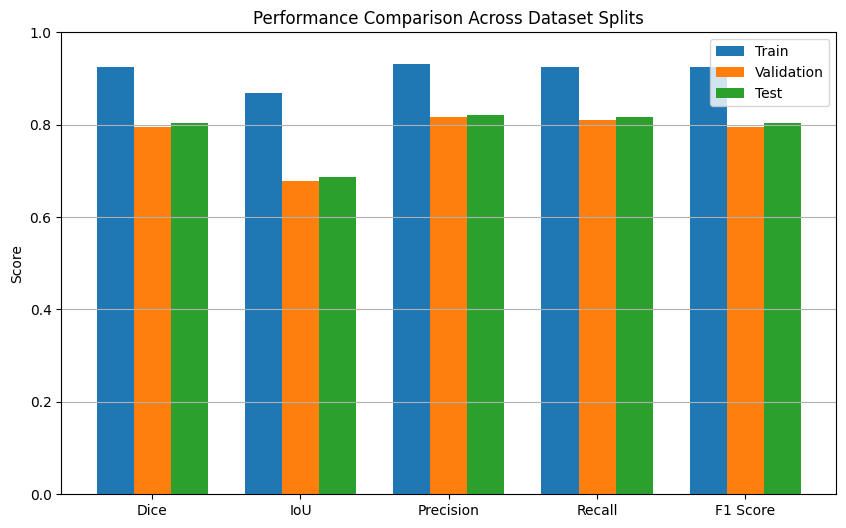

In [58]:
import numpy as np

metrics = ["Dice","IoU","Precision","Recall","F1 Score"]

train = [
    train_results["Dice"],
    train_results["IoU"],
    train_results["Precision"],
    train_results["Recall"],
    train_results["F1"]
]

val = [
    val_results["Dice"],
    val_results["IoU"],
    val_results["Precision"],
    val_results["Recall"],
    val_results["F1"]
]

test = [
    test_results["Dice"],
    test_results["IoU"],
    test_results["Precision"],
    test_results["Recall"],
    test_results["F1"]
]

x = np.arange(len(metrics))
width = 0.25

plt.figure(figsize=(10,6))

plt.bar(x-width, train, width, label="Train")
plt.bar(x, val, width, label="Validation")
plt.bar(x+width, test, width, label="Test")

plt.xticks(x, metrics)
plt.ylabel("Score")
plt.ylim(0,1)
plt.title("Performance Comparison Across Dataset Splits")
plt.legend()

plt.grid(axis='y')

plt.show()